# Detección de Muelas del Juicio — Semana 2: Preparación del Dataset

**Materia:** Redes Neuronales  
**Docente:** Ing. Pablo Marinozi  
**Repo:** https://github.com/JulianOliveraBalls/dentex-wisdom-teeth

---

## Contexto del problema

Se busca detectar **muelas del juicio** (terceros molares) en radiografías panorámicas
dentales y clasificar su estado:

| Clase | Descripción clínica | Señal visual |
|-------|---------------------|-------------|
| `erupted` (0) | Muela erupcionada normalmente | Diente en posición normal — similar a molares adyacentes |
| `impacted` (1) | Muela retenida/impactada | Diente en posición horizontal o diagonal — señal distintiva |

### Decisiones de diseño

| Problema | Solución |
|----------|----------|
| Pocas imágenes (~430 con muelas) | Augmentation + cuadrantes + dataset adicional ExAn-MTM |
| Desbalance erupted/impacted (~37/63%) | Augmentation estratificada en train |
| Panorámicas anchas (~2800px) | División en 4 cuadrantes solapados → muelas más grandes en el frame |
| `erupted` visualmente ambigua | Limitación documentada — requiere contexto global del arco dental |

| Sección | Contenido |
|---------|----------|
| 0 | Setup — detección automática Colab/local |
| a | Carga y estructura del dataset |
| b | Particionado estratificado 70/5/25 |
| c | Preprocesamiento |
| d | Data augmentation (6 estrategias) |
| e | DataLoaders + verificación del batch |
| f | Exportar CSVs de splits |


## Sección 0 — Setup

In [1]:
import subprocess, sys, os, gc, json, random, warnings, shutil, zipfile
from pathlib import Path
from collections import Counter, defaultdict
warnings.filterwarnings('ignore')

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *pkgs, '-q'])

try:
    import ultralytics, sklearn, huggingface_hub
except ImportError:
    pip_install('ultralytics', 'scikit-learn', 'huggingface_hub')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from huggingface_hub import hf_hub_download as hf_dl

# ── Utilidades (antes de la detección para poder usarlas en el bloque) ────────
def log(msg, level='INFO'):
    icons = {'INFO':'[INFO]','OK':'[OK]  ','WARN':'[WARN]','ERR':'[ERR] ','DATA':'[DATA]'}
    print(f'{icons.get(level,"[INFO]")} {msg}')

def is_real_file(p):
    try: return Path(p).resolve().exists() and Path(p).stat().st_size > 0
    except: return False

def split_existe(d):
    return Path(d).exists() and all(
        len(list((Path(d)/'images'/s).glob('*.*'))) > 0
        for s in ['train','val','test'])

# ── Detección automática Colab / local ────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = os.path.exists('/content') and not os.path.exists('C:/Users')
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive; drive.mount('/drive')
    REPO_ROOT = Path('/content/dentex-wisdom-teeth')
    if not REPO_ROOT.exists():
        subprocess.run(['git', 'clone',
                        'https://github.com/JulianOliveraBalls/dentex-wisdom-teeth.git',
                        str(REPO_ROOT)], check=True)
    DRIVE_DIR = Path('/drive/MyDrive/dentex_runs')
else:
    _nb_path = Path(globals().get('__vsc_ipynb_file__',
                    globals().get('__file__', str(Path.cwd() / 'dev' / 'notebook.ipynb'))))
    REPO_ROOT = _nb_path.parent.parent
    DRIVE_DIR = REPO_ROOT / 'dev'
    log(f'Modo local — REPO_ROOT: {REPO_ROOT}', 'OK')

# ── Paths derivados del repo ──────────────────────────────────────────────────
DATA_DIR    = REPO_ROOT / 'data'
RAW_DIR     = DATA_DIR / 'raw'
DENTEX_DIR  = RAW_DIR / 'dentex_raw'
EXAN_DIR    = RAW_DIR / 'exan_mtm'
PROCESSED   = DATA_DIR / 'processed'
YOLO_DIR    = PROCESSED / 'yolo_dataset'
YOLO_MERGED = PROCESSED / 'yolo_merged'
OUTPUTS_DIR = DATA_DIR / 'outputs'
SRC_DIR     = REPO_ROOT / 'src'
for d in [OUTPUTS_DIR, SRC_DIR, DENTEX_DIR, EXAN_DIR]:
    d.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(SRC_DIR))

SEED = 42
BATCH_SIZE = 8
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

log(f'REPO_ROOT: {REPO_ROOT}', 'DATA')
log(f'IN_COLAB:  {IN_COLAB}   device: {device}   SEED: {SEED}', 'OK')

Mounted at /drive
[DATA] REPO_ROOT: /content/dentex-wisdom-teeth
[OK]   IN_COLAB:  True   device: cuda   SEED: 42


## a) Carga y organización del dataset

### Fuentes

| Dataset | Fuente | Imágenes | Formato | Licencia |
|---------|--------|----------|---------|----------|
| **DENTEX MICCAI 2023** | [HuggingFace](https://huggingface.co/datasets/ibrahimhamamci/DENTEX) | 705 anotadas | COCO JSON | CC-BY |
| **ExAn-MTM** | [Kaggle](https://www.kaggle.com/datasets/ikyd26/expert-annotated-mandibular-third-molar-dataset) + [Figshare](https://doi.org/10.6084/m9.figshare.21621705) | 973 panorámicas | YOLO TXT | CC-BY |

Las dos fuentes usan el mismo mapeo de clases: `0=erupted`, `1=impacted`.

### Por qué no ImageFolder

`ImageFolder` asume una imagen = una clase (clasificación). Nuestro problema es
**detección**: cada imagen puede tener múltiples boxes con distintas clases.
Se implementa `DentexDataset(torch.utils.data.Dataset)` personalizado.

### Descarga automática

El script `data/download.py` descarga todo desde cero. Este notebook llama
las mismas funciones internamente con verificación de caché ya que estamos en Colab


In [2]:
import requests as _req

# ── Descarga DENTEX ───────────────────────────────────────────────────────────
json_files = [f for f in DENTEX_DIR.rglob('*.json') if is_real_file(f)] if DENTEX_DIR.exists() else []
if not any('disease' in f.name.lower() for f in json_files):
    log('Descargando DENTEX desde HuggingFace...', 'WARN')
    for fname, cname in [('DENTEX/training_data.zip','training_data'),
                          ('DENTEX/validation_data.zip','validation_data')]:
        check = DENTEX_DIR / 'DENTEX' / cname
        if check.exists() and len(list(check.rglob('*.png'))) > 0: continue
        zp = hf_dl(repo_id='ibrahimhamamci/DENTEX', repo_type='dataset',
                   filename=fname, local_dir=str(DENTEX_DIR))
        with zipfile.ZipFile(zp, 'r') as z: z.extractall(str(DENTEX_DIR/'DENTEX'))
        os.remove(zp); log(f'{fname} extraído', 'OK')
    json_files = [f for f in DENTEX_DIR.rglob('*.json') if is_real_file(f)]
else:
    log('DENTEX ya descargado', 'OK')

TRAIN_JSON = next((j for j in json_files if 'disease' in j.name.lower()), None)
if not TRAIN_JSON: raise FileNotFoundError('JSON DENTEX no encontrado')
IMG_DIR_C = next((c for c in [TRAIN_JSON.parent/'xrays', TRAIN_JSON.parent.parent/'xrays']
                  if c.exists()), TRAIN_JSON.parent/'xrays')
with open(TRAIN_JSON) as f: data_c = json.load(f)
id2img = {img['id']: img for img in data_c['images']}
wisdom = defaultdict(list)
for ann in data_c['annotations']:
    if ann.get('category_id_2') == 7: wisdom[ann['image_id']].append(ann)

def classify_image(img_id):
    return 'impacted' if any(a.get('category_id_3')==0 for a in wisdom[img_id]) else 'erupted'

counts = Counter(classify_image(i) for i in wisdom)
total  = sum(counts.values())
log(f'Imágenes con muela del juicio: {total}', 'DATA')
log(f'  erupted:  {counts["erupted"]}  ({counts["erupted"]/total*100:.1f}%)', 'DATA')
log(f'  impacted: {counts["impacted"]}  ({counts["impacted"]/total*100:.1f}%)', 'DATA')


[WARN] Descargando DENTEX desde HuggingFace...


DENTEX/training_data.zip:   0%|          | 0.00/10.9G [00:00<?, ?B/s]

[OK]   DENTEX/training_data.zip extraído


DENTEX/validation_data.zip:   0%|          | 0.00/150M [00:00<?, ?B/s]

[OK]   DENTEX/validation_data.zip extraído
[DATA] Imágenes con muela del juicio: 440
[DATA]   erupted:  186  (42.3%)
[DATA]   impacted: 254  (57.7%)


In [3]:
import subprocess, os, zipfile, requests as _req
from pathlib import Path

# ── Configurar Kaggle ─────────────────────────────────────────────────────────
KAGGLE_TOKEN = 'KGAT_9541105c6a2fec68be43345f171bc2c9'
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_TOKEN
token_path = Path.home() / '.kaggle' / 'access_token'
token_path.parent.mkdir(exist_ok=True)
token_path.write_text(KAGGLE_TOKEN); token_path.chmod(0o600)
try: import kaggle as _kaggle
except ImportError: pip_install('kaggle')

# ── Paths ExAn-MTM ────────────────────────────────────────────────────────────
EXAN_BASE      = EXAN_DIR / 'ExAn-MTM dataset'
EXAN_TRAIN_IMG = EXAN_BASE / 'train' / 'images'
EXAN_TRAIN_LBL = EXAN_BASE / 'train' / 'labels'
EXAN_VAL_IMG   = EXAN_BASE / 'valid' / 'images'
EXAN_VAL_LBL   = EXAN_BASE / 'valid' / 'labels'
EXAN_TRAIN_IMG.mkdir(parents=True, exist_ok=True)
EXAN_VAL_IMG.mkdir(parents=True, exist_ok=True)

# ── 1. Labels desde Kaggle ────────────────────────────────────────────────────
n_labels = len([p for p in EXAN_TRAIN_LBL.glob('*.txt')
                if p.name != 'readme.txt']) if EXAN_TRAIN_LBL.exists() else 0
if n_labels >= 875:
    log(f'Labels ya descargados: {n_labels}', 'OK')
else:
    log('Descargando labels desde Kaggle...', 'WARN')
    # Intentar CLI primero, luego API Python
    r = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d',
         'ikyd26/expert-annotated-mandibular-third-molar-dataset',
         '--path', str(EXAN_DIR), '--unzip'],
        capture_output=True, text=True,
        env={**os.environ, 'KAGGLE_API_TOKEN': KAGGLE_TOKEN})
    if r.returncode != 0:
        log(f'CLI falló: {r.stderr[:100]} — intentando API Python...', 'WARN')
        try:
            import kaggle
            kaggle.api.authenticate()
            kaggle.api.dataset_download_files(
                'ikyd26/expert-annotated-mandibular-third-molar-dataset',
                path=str(EXAN_DIR), unzip=True)
            log('Labels descargados via API Python', 'OK')
        except Exception as e:
            log(f'Error: {e}', 'ERR')
    else:
        log('Labels descargados via CLI', 'OK')
    n_labels = len([p for p in EXAN_TRAIN_LBL.glob('*.txt') if p.name != 'readme.txt'])
    log(f'Labels disponibles: {n_labels}', 'DATA')

# ── 2. Imágenes desde Figshare ────────────────────────────────────────────────
n_imgs = len(list(EXAN_TRAIN_IMG.glob('*.jpg')))
if n_imgs >= 875:
    log(f'Imágenes ya extraídas: {n_imgs}', 'OK')
else:
    ZIP_PATH = EXAN_DIR / 'dental_dataset.zip'
    if not ZIP_PATH.exists() or ZIP_PATH.stat().st_size < 1e9:
        log('Descargando imágenes UESB desde Figshare (1.6 GB)...', 'WARN')
        with _req.get('https://ndownloader.figshare.com/files/38322366', stream=True) as resp:
            resp.raise_for_status()
            total_b = int(resp.headers.get('content-length', 0))
            downloaded = 0
            with open(ZIP_PATH, 'wb') as f:
                for chunk in resp.iter_content(chunk_size=1024*1024):
                    f.write(chunk); downloaded += len(chunk)
                    if downloaded % (200*1024*1024) == 0:
                        log(f'  {downloaded/1e6:.0f}/{total_b/1e6:.0f} MB', 'DATA')
        log(f'ZIP descargado: {ZIP_PATH.stat().st_size/1e9:.2f} GB', 'OK')
    else:
        log(f'ZIP ya existe: {ZIP_PATH.stat().st_size/1e9:.2f} GB', 'OK')

    log('Extrayendo imágenes...', 'WARN')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        all_names = z.namelist()
        # Mapeo stem → path dentro del ZIP
        imgs_tr  = {Path(n).stem: n for n in all_names
                    if 'Dataset and code/train/images' in n
                    and n.lower().endswith(('.jpg', '.jpeg', '.png'))}
        imgs_val = {Path(n).stem: n for n in all_names
                    if 'Dataset and code/test/images' in n
                    and n.lower().endswith(('.jpg', '.jpeg', '.png'))}
        log(f'Imgs en ZIP — train: {len(imgs_tr)}  val: {len(imgs_val)}', 'DATA')

        # Verificar que los stems coinciden con los labels
        label_stems_tr  = [p.stem for p in EXAN_TRAIN_LBL.glob('*.txt') if p.name != 'readme.txt']
        label_stems_val = [p.stem for p in EXAN_VAL_LBL.glob('*.txt')   if p.name != 'readme.txt']
        match_tr  = sum(1 for s in label_stems_tr  if s in imgs_tr or s in imgs_val)
        match_val = sum(1 for s in label_stems_val if s in imgs_tr or s in imgs_val)
        log(f'Matches — train: {match_tr}/{len(label_stems_tr)}  val: {match_val}/{len(label_stems_val)}', 'DATA')

        extr_tr = extr_val = 0
        for stem in label_stems_tr:
            dst = EXAN_TRAIN_IMG / f'{stem}.jpg'
            if dst.exists(): extr_tr += 1; continue
            src = imgs_tr.get(stem) or imgs_val.get(stem)
            if src: dst.write_bytes(z.read(src)); extr_tr += 1
        for stem in label_stems_val:
            dst = EXAN_VAL_IMG / f'{stem}.jpg'
            if dst.exists(): extr_val += 1; continue
            src = imgs_tr.get(stem) or imgs_val.get(stem)
            if src: dst.write_bytes(z.read(src)); extr_val += 1

    log(f'ExAn-MTM extraído: {extr_tr} train, {extr_val} val', 'OK')

log(f'ExAn-MTM final: {len(list(EXAN_TRAIN_IMG.glob("*.jpg")))} train, '
    f'{len(list(EXAN_VAL_IMG.glob("*.jpg")))} val', 'DATA')

[WARN] Descargando labels desde Kaggle...
[OK]   Labels descargados via CLI
[DATA] Labels disponibles: 875
[WARN] Descargando imágenes UESB desde Figshare (1.6 GB)...
[DATA]   210/1649 MB
[DATA]   419/1649 MB
[DATA]   629/1649 MB
[DATA]   839/1649 MB
[DATA]   1049/1649 MB
[DATA]   1258/1649 MB
[DATA]   1468/1649 MB
[OK]   ZIP descargado: 1.65 GB
[WARN] Extrayendo imágenes...
[DATA] Imgs en ZIP — train: 1500  val: 478
[DATA] Matches — train: 875/875  val: 98/98
[OK]   ExAn-MTM extraído: 875 train, 98 val
[DATA] ExAn-MTM final: 875 train, 98 val


## b) Particionado

| Decisión | Valor | Justificación |
|----------|-------|---------------|
| Proporciones | **70/5/25** | Train máximo, test representativo |
| Estratificado | `stratify=labels` | Mantiene ratio erupted/impacted en los 3 splits |
| Semilla | `seed=42` | Reproducibilidad garantizada |
| Test set | Solo DENTEX | Evaluación honesta — ExAn-MTM nunca aparece en test |

### Expansión con cuadrantes (solo train)

```
panorámica 2800×1300px  →  4 cuadrantes con 10% solapamiento
308 imgs train  →  ~1744 imgs train   (308 × 4 cuadrantes × 2 con flip)
```

Las bounding boxes se reproyectan al sistema de coordenadas de cada cuadrante.
Solo se incluyen cuadrantes con al menos 1 box con >=50% de área visible.


In [4]:
def generar_split_yolo(yolo_out, img_ids, labels, wisdom_dict, id2img_dict, img_dir):
    ids_tr,ids_tmp,_,y_tmp = train_test_split(img_ids,labels,test_size=0.30,stratify=labels,random_state=SEED)
    ids_val,ids_test,_,_  = train_test_split(ids_tmp,y_tmp,test_size=0.833,stratify=y_tmp,random_state=SEED)
    for split,ids in {'train':ids_tr,'val':ids_val,'test':ids_test}.items():
        (yolo_out/'images'/split).mkdir(parents=True,exist_ok=True)
        (yolo_out/'labels'/split).mkdir(parents=True,exist_ok=True)
        for img_id in ids:
            info=id2img_dict[img_id]; src=img_dir/Path(info['file_name']).name
            if not is_real_file(src): continue
            pil=Image.open(src); W,H=pil.size
            dst=yolo_out/'images'/split/src.name
            if not dst.exists(): os.symlink(src.resolve(),dst)
            lines=[]
            for ann in wisdom_dict[img_id]:
                x,y,bw,bh=ann['bbox']
                xc=min(max((x+bw/2)/W,0),1); yc=min(max((y+bh/2)/H,0),1)
                wn=min(max(bw/W,0),1); hn=min(max(bh/H,0),1)
                cls=1 if ann.get('category_id_3')==0 else 0
                lines.append(f'{cls} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}')
            (yolo_out/'labels'/split/(src.stem+'.txt')).write_text('\n'.join(lines))
    (yolo_out/'dataset.yaml').write_text(
        f'path: {yolo_out}\ntrain: images/train\nval:   images/val\n'
        f'test:  images/test\nnc: 2\nnames:\n  0: erupted\n  1: impacted\n')

def expandir_cuadrantes(src,dst,overlap=0.1):
    for split in ['val','test']:
        for sub in ['images','labels']:
            d=dst/sub/split; d.mkdir(parents=True,exist_ok=True)
            for f in (src/sub/split).glob('*.*'):
                lnk=d/f.name
                if not lnk.exists(): os.symlink(f.resolve(),lnk)
    (dst/'images'/'train').mkdir(parents=True,exist_ok=True)
    (dst/'labels'/'train').mkdir(parents=True,exist_ok=True)
    n_o=n_q=0
    for img_p in sorted((src/'images'/'train').glob('*.png')):
        lbl_p=src/'labels'/'train'/(img_p.stem+'.txt')
        if not lbl_p.exists(): continue
        pil=Image.open(img_p).convert('RGB'); W,H=pil.size
        d_o=dst/'images'/'train'/img_p.name
        if not d_o.exists(): os.symlink(img_p.resolve(),d_o)
        shutil.copy2(lbl_p,dst/'labels'/'train'/lbl_p.name); n_o+=1
        boxes=[(int(p[0]),*map(float,p[1:])) for ln in lbl_p.read_text().strip().split('\n') if ln for p in [ln.split()]]
        ox=int(W*overlap/2); oy=int(H*overlap/2)
        quads=[('tl',0,0,W//2+ox,H//2+oy),('tr',W//2-ox,0,W,H//2+oy),
               ('bl',0,H//2-oy,W//2+ox,H),('br',W//2-ox,H//2-oy,W,H)]
        for qn,x1,y1,x2,y2 in quads:
            qW,qH=x2-x1,y2-y1; crop=pil.crop((x1,y1,x2,y2)); qlines=[]
            for cls,xc,yc,bw,bh in boxes:
                ax1=xc*W-bw*W/2; ay1=yc*H-bh*H/2; ax2=xc*W+bw*W/2; ay2=yc*H+bh*H/2
                ix1=max(ax1,x1)-x1; iy1=max(ay1,y1)-y1; ix2=min(ax2,x2)-x1; iy2=min(ay2,y2)-y1
                if ix2<=ix1 or iy2<=iy1: continue
                if (ix2-ix1)*(iy2-iy1)/(bw*W*bh*H)<0.5: continue
                nxc=min(max((ix1+ix2)/2/qW,0),1); nyc=min(max((iy1+iy2)/2/qH,0),1)
                nw=min(max((ix2-ix1)/qW,0),1); nh=min(max((iy2-iy1)/qH,0),1)
                qlines.append(f'{cls} {nxc:.6f} {nyc:.6f} {nw:.6f} {nh:.6f}')
            if not qlines: continue
            st=f'{img_p.stem}_{qn}'; crop.save(str(dst/'images'/'train'/(st+'.png')))
            (dst/'labels'/'train'/(st+'.txt')).write_text('\n'.join(qlines)); n_q+=1
            fl=crop.transpose(Image.FLIP_LEFT_RIGHT)
            flines=[f'{l.split()[0]} {1-float(l.split()[1]):.6f} {" ".join(l.split()[2:])}' for l in qlines]
            sf=f'{img_p.stem}_{qn}_flip'; fl.save(str(dst/'images'/'train'/(sf+'.png')))
            (dst/'labels'/'train'/(sf+'.txt')).write_text('\n'.join(flines)); n_q+=1
    (dst/'dataset.yaml').write_text(
        f'path: {dst}\ntrain: images/train\nval:   images/val\n'
        f'test:  images/test\nnc: 2\nnames:\n  0: erupted\n  1: impacted\n')
    return n_o,n_q

def construir_merged(src_dentex,exan_ti,exan_tl,exan_vi,exan_vl,dst):
    for split in ['train','val','test']:
        (dst/'images'/split).mkdir(parents=True,exist_ok=True)
        (dst/'labels'/split).mkdir(parents=True,exist_ok=True)
    n=defaultdict(int)
    for split in ['train','val','test']:
        for img_p in sorted(list((src_dentex/'images'/split).glob('*.png'))+
                             list((src_dentex/'images'/split).glob('*.jpg'))):
            lbl_p=src_dentex/'labels'/split/(img_p.stem+'.txt')
            if not lbl_p.exists(): continue
            di=dst/'images'/split/f'dentex_{img_p.name}'; dl=dst/'labels'/split/f'dentex_{img_p.stem}.txt'
            if not di.exists():
                real=Path(os.path.realpath(str(img_p)))
                if real.exists() and real!=di: os.symlink(real,di)
                else: shutil.copy2(str(img_p),str(di))
            if not dl.exists(): shutil.copy2(str(lbl_p),str(dl))
            n[f'dentex_{split}']+=1
    for imgs_src,lbl_src,split_dst in [(exan_ti,exan_tl,'train'),(exan_vi,exan_vl,'val')]:
        if not imgs_src or not imgs_src.exists(): continue
        for img_p in sorted(list(imgs_src.glob('*.jpg'))+list(imgs_src.glob('*.png'))):
            lbl_p=lbl_src/(img_p.stem+'.txt') if lbl_src else None
            if not lbl_p or not lbl_p.exists(): continue
            di=dst/'images'/split_dst/f'exan_{img_p.name}'; dl=dst/'labels'/split_dst/f'exan_{img_p.stem}.txt'
            if not di.exists(): os.symlink(img_p.resolve(),di)
            if not dl.exists(): shutil.copy2(str(lbl_p),str(dl))
            n[f'exan_{split_dst}']+=1
    (dst/'dataset.yaml').write_text(
        f'path: {dst}\ntrain: images/train\nval:   images/val\n'
        f'test:  images/test\nnc: 2\nnames:\n  0: erupted\n  1: impacted\n')
    return dict(n)

# Generar todos los datasets
YOLO_QUAD = PROCESSED / 'yolo_quad_flip'
if split_existe(YOLO_DIR): log(f'yolo_dataset: ya existe','OK')
else:
    img_ids=list(wisdom.keys()); labels=[classify_image(i) for i in img_ids]
    generar_split_yolo(YOLO_DIR,img_ids,labels,wisdom,id2img,IMG_DIR_C); log('yolo_dataset generado','OK')
if split_existe(YOLO_QUAD): log(f'yolo_quad_flip: ya existe','OK')
else:
    n_o,n_q=expandir_cuadrantes(YOLO_DIR,YOLO_QUAD); log(f'yolo_quad_flip: {n_o+n_q} imgs train','OK')
n_exan = len(list((YOLO_MERGED/'images'/'train').glob('exan_*'))) if YOLO_MERGED.exists() else 0
if n_exan >= 800:
    log(f'yolo_merged OK: {len(list((YOLO_MERGED/"images"/"train").glob("*.*")))} imgs (exan={n_exan})', 'OK')
else:
    log(f'yolo_merged sin ExAn-MTM (exan={n_exan}) — reconstruyendo...', 'WARN')
    if YOLO_MERGED.exists(): shutil.rmtree(str(YOLO_MERGED))
    stats=construir_merged(YOLO_QUAD,EXAN_TRAIN_IMG,EXAN_TRAIN_LBL,EXAN_VAL_IMG,EXAN_VAL_LBL,YOLO_MERGED)
    for k,v in stats.items(): log(f'  {k}: {v}','DATA')

log('Distribución por split (seed=42, estratificado):','DATA')
for split in ['train','val','test']:
    img_d=YOLO_MERGED/'images'/split; lbl_d=YOLO_MERGED/'labels'/split
    n=len(list(img_d.glob('*.*'))); c0=c1=0
    for lbl in lbl_d.glob('*.txt'):
        for line in lbl.read_text().strip().split('\n'):
            if line: (c0 if int(line.split()[0])==0 else None) or None
            if line: c0+=int(line.split()[0])==0; c1+=int(line.split()[0])==1
    log(f'  {split:5s}: {n:5d} imgs | erupted={c0} ({c0/max(c0+c1,1)*100:.0f}%) impacted={c1} ({c1/max(c0+c1,1)*100:.0f}%)','DATA')


[OK]   yolo_dataset generado
[OK]   yolo_quad_flip: 1744 imgs train
[WARN] yolo_merged sin ExAn-MTM (exan=0) — reconstruyendo...
[DATA]   dentex_train: 1744
[DATA]   dentex_val: 22
[DATA]   dentex_test: 110
[DATA]   exan_train: 875
[DATA]   exan_val: 98
[DATA] Distribución por split (seed=42, estratificado):
[DATA]   train:  2619 imgs | erupted=1423 (37%) impacted=2379 (63%)
[DATA]   val  :   120 imgs | erupted=80 (35%) impacted=147 (65%)
[DATA]   test :   110 imgs | erupted=84 (39%) impacted=131 (61%)


## c) Preprocesamiento

| Paso | Valor | Justificación |
|------|-------|---------------|
| `Resize(640,640)` | 640×640 px | Resolución nativa de YOLOv8 |
| `ToTensor()` | float32 [0,1] | Convierte PIL uint8 [0,255] |
| `Normalize(ImageNet)` | mean/std de COCO | El backbone fue preentrenado con estas estadísticas |

Las panorámicas son grises (escala de grises). Se cargan como RGB: los 3 canales son idénticos.

**¿Por qué 640 y no 224?** YOLOv8 necesita resolver objetos pequeños — las muelas
ocupan ~30-50 px en panorámicas completas. Con 224px serían ~8 px, indetectables.


In [5]:
# Importar augmentations desde src/ (ya está en sys.path)
try:
    from augmentations_config import AUGMENTATIONS, BASE_TRANSFORM, MEAN, STD
    log('augmentations_config importado desde src/', 'OK')
except ImportError:
    log('src/augmentations_config.py no encontrado — definiendo inline', 'WARN')
    MEAN = [0.485, 0.456, 0.406]; STD = [0.229, 0.224, 0.225]
    BASE_TRANSFORM = T.Compose([
        T.Resize((640,640)), T.ToTensor(), T.Normalize(mean=MEAN,std=STD)])
    AUGMENTATIONS = {'A_baseline': BASE_TRANSFORM}

MEAN_T = torch.tensor(MEAN).view(3,1,1)
STD_T  = torch.tensor(STD).view(3,1,1)

class DentexDataset(Dataset):
    """Dataset YOLO de radiografías panorámicas.
    Args:
        split:    'train', 'val' o 'test'
        yolo_dir: Path al directorio con images/ y labels/
        transform: torchvision transform a aplicar
    """
    CLASS_NAMES  = {0:'erupted', 1:'impacted'}
    CLASS_COLORS = {0:'#44CC44', 1:'#FF4444'}

    def __init__(self, split, yolo_dir, transform=None):
        self.split=split; self.yolo_dir=Path(yolo_dir); self.transform=transform
        self.img_dir=self.yolo_dir/'images'/split; self.lbl_dir=self.yolo_dir/'labels'/split
        self.samples=[(p,self.lbl_dir/(p.stem+'.txt'))
            for p in sorted(list(self.img_dir.glob('*.png'))+list(self.img_dir.glob('*.jpg')))
            if (self.lbl_dir/(p.stem+'.txt')).exists()]
        self.class_counts=Counter()
        for _,lp in self.samples:
            for line in lp.read_text().strip().split('\n'):
                if line: self.class_counts[int(line.split()[0])]+=1
        log(f'DentexDataset [{split}]: {len(self.samples)} imgs | '
            f'erupted={self.class_counts[0]} impacted={self.class_counts[1]}','OK')

    def __len__(self): return len(self.samples)

    def __getitem__(self,idx):
        img_path,lbl_path=self.samples[idx]
        image=Image.open(img_path).convert('RGB')
        boxes,labels=[],[]
        for line in lbl_path.read_text().strip().split('\n'):
            if line: p=line.split(); labels.append(int(p[0])); boxes.append(list(map(float,p[1:])))
        if self.transform: image=self.transform(image)
        return image, {'boxes':torch.tensor(boxes,dtype=torch.float32) if boxes else torch.zeros((0,4)),
                       'labels':torch.tensor(labels,dtype=torch.long) if labels else torch.zeros(0,dtype=torch.long),
                       'image_id':img_path.stem}

    def get_image_raw(self,idx): return Image.open(self.samples[idx][0]).convert('RGB')

def collate_fn(batch):
    """Agrupa batch con distinto número de boxes por imagen."""
    return torch.stack([b[0] for b in batch]), [b[1] for b in batch]

# Verificación
ds_tmp=DentexDataset('train',YOLO_MERGED,transform=BASE_TRANSFORM)
img_raw=ds_tmp.get_image_raw(0); img_t,_=ds_tmp[0]
log(f'PIL: {img_raw.size} modo={img_raw.mode}  →  Tensor: {tuple(img_t.shape)} [{img_t.min():.2f},{img_t.max():.2f}]','DATA')
arr=np.array(img_raw)
log(f'Grises confirmado (R==G=={np.array_equal(arr[:,:,0],arr[:,:,1])}, R==B=={np.array_equal(arr[:,:,0],arr[:,:,2])})','DATA')


[OK]   augmentations_config importado desde src/
[OK]   DentexDataset [train]: 2619 imgs | erupted=1423 impacted=2379
[DATA] PIL: (2850, 1316) modo=RGB  →  Tensor: (3, 640, 640) [-2.12,2.64]
[DATA] Grises confirmado (R==G==True, R==B==True)


## d) Data Augmentation

Las 6 estrategias están definidas en `src/augmentations_config.py`.
Se aplican **únicamente al train**. Val y test siempre usan `BASE_TRANSFORM`.

| ID | Nombre | Transformaciones |
|----|--------|------------------|
| A | `baseline` | Solo resize+normalize — referencia limpia |
| B | `flips` | + HorizontalFlip(p=0.5) — simetría bilateral del arco dental |
| C | `color` | + ColorJitter + RandomAffine(5°) — variabilidad entre equipos |
| D | `geometric` | + RandomAffine(8°,scale) + RandomErasing — artefactos metálicos |
| E | `full` | B + C + D combinados |
| F | `mixaug` | E + GaussianBlur — variabilidad de resolución |

**Excluidas:** VerticalFlip (anatómicamente incorrecto), mosaic/mixup (mezcla anatomías distintas).


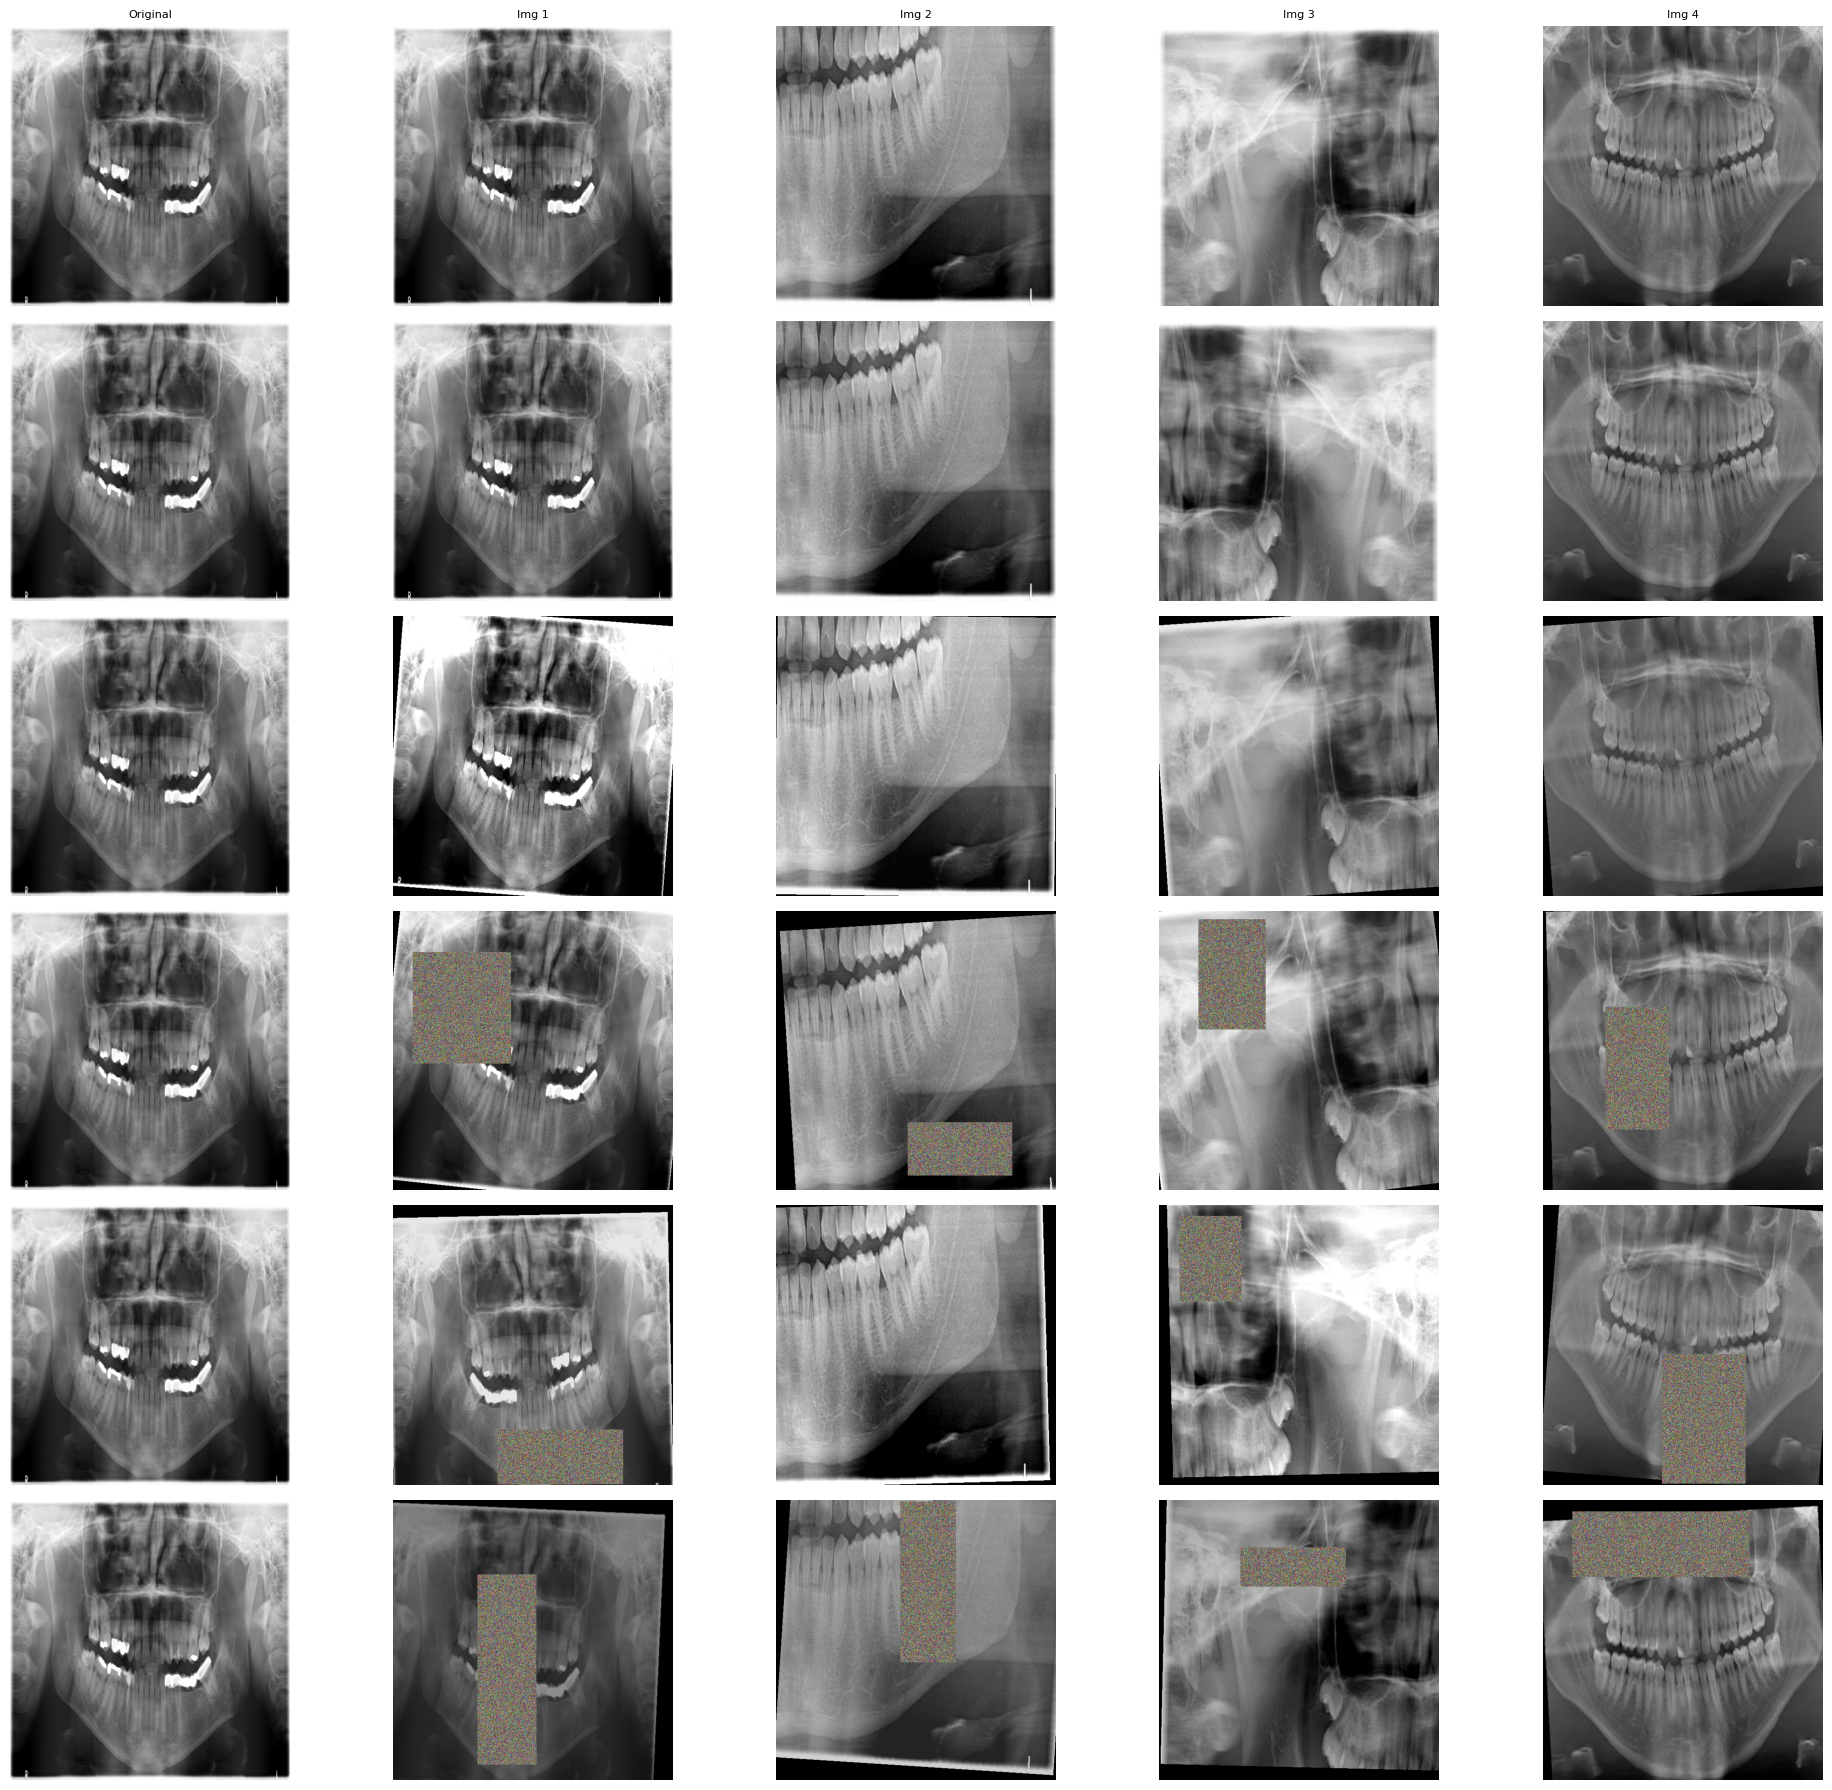

In [6]:
ERASING_VIS = T.RandomErasing(p=0.9, scale=(0.05,0.15), value='random')

def get_transform_vis(aug_name):
    t = AUGMENTATIONS[aug_name]
    if aug_name in ('D_geometric','E_full','F_mixaug'):
        steps = [s for s in t.transforms if not isinstance(s, T.RandomErasing)]
        return T.Compose(steps + [ERASING_VIS])
    return t

sample_raws = [ds_tmp.get_image_raw(i*len(ds_tmp)//4) for i in range(4)]
N_AUG = len(AUGMENTATIONS)

fig, axes = plt.subplots(N_AUG, 5, figsize=(20, 3*N_AUG))
axes = np.array(axes).reshape(N_AUG, 5)  # <- fuerza siempre 2D

for row, (aug_name, _) in enumerate(AUGMENTATIONS.items()):
    aug_vis = get_transform_vis(aug_name)
    axes[row][0].imshow(np.array(sample_raws[0].resize((320,320))))
    axes[row][0].set_ylabel(aug_name, fontsize=8, rotation=0, labelpad=100, va='center')
    if row == 0: axes[row][0].set_title('Original', fontsize=8)
    axes[row][0].axis('off')
    for col, raw in enumerate(sample_raws):
        aug_t = aug_vis(raw.convert('RGB').resize((640,640)))
        if isinstance(aug_t, torch.Tensor):
            vis = (aug_t*STD_T+MEAN_T).clamp(0,1).permute(1,2,0).numpy()
        else:
            vis = np.array(aug_t)
        axes[row][col+1].imshow(vis)
        if row == 0: axes[row][col+1].set_title(f'Img {col+1}', fontsize=8)
        axes[row][col+1].axis('off')

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR/'augmentations_comparacion.png'), dpi=80, bbox_inches='tight')
plt.show()

## e) DataLoaders y verificación del batch

| Parámetro | Train | Val/Test | Justificación |
|-----------|-------|----------|---------------|
| `batch_size` | 8 | 8 | Limitado por VRAM T4 con imágenes 640×640 |
| `shuffle` | True | False | Train: variabilidad. Val/Test: deterministas |
| `collate_fn` | personalizado | personalizado | Distinto número de boxes por imagen |
| `num_workers` | 2 | 2 | Carga paralela sin saturar RAM de Colab |


In [7]:
log('DataLoaders de entrenamiento por augmentation:', 'OK')
for aug_name, aug_transform in AUGMENTATIONS.items():
    ds_tmp_aug = DentexDataset('train', YOLO_MERGED, transform=aug_transform)
    dl_tmp = DataLoader(ds_tmp_aug, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, collate_fn=collate_fn)
    log(f'  dl_train[{aug_name}]: {len(ds_tmp_aug)} imgs, {len(dl_tmp)} batches', 'DATA')
    del ds_tmp_aug, dl_tmp

ds_train = DentexDataset('train', YOLO_MERGED, transform=AUGMENTATIONS['E_full'])
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, collate_fn=collate_fn,
                      pin_memory=torch.cuda.is_available())

# Val y test SIEMPRE sin augmentation
ds_val  = DentexDataset('val',  YOLO_MERGED, transform=BASE_TRANSFORM)
ds_test = DentexDataset('test', YOLO_MERGED, transform=BASE_TRANSFORM)
dl_val  = DataLoader(ds_val,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)

log(f'dl_train (E_full): {len(ds_train)} imgs, {len(dl_train)} batches', 'DATA')
log(f'dl_val:  {len(ds_val)} imgs  |  dl_test: {len(ds_test)} imgs', 'OK')

ds_verify = DentexDataset('train', YOLO_MERGED, transform=AUGMENTATIONS['A_baseline'])
dl_verify = DataLoader(ds_verify, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=2, collate_fn=collate_fn)
log(f'dl_verify (A_baseline): listo para verificación visual', 'OK')

[OK]   DataLoaders de entrenamiento por augmentation:
[OK]   DentexDataset [train]: 2619 imgs | erupted=1423 impacted=2379
[DATA]   dl_train[A_baseline]: 2619 imgs, 328 batches
[OK]   DentexDataset [train]: 2619 imgs | erupted=1423 impacted=2379
[DATA]   dl_train[B_flips]: 2619 imgs, 328 batches
[OK]   DentexDataset [train]: 2619 imgs | erupted=1423 impacted=2379
[DATA]   dl_train[C_color]: 2619 imgs, 328 batches
[OK]   DentexDataset [train]: 2619 imgs | erupted=1423 impacted=2379
[DATA]   dl_train[D_geometric]: 2619 imgs, 328 batches
[OK]   DentexDataset [train]: 2619 imgs | erupted=1423 impacted=2379
[DATA]   dl_train[E_full]: 2619 imgs, 328 batches
[OK]   DentexDataset [train]: 2619 imgs | erupted=1423 impacted=2379
[DATA]   dl_train[F_mixaug]: 2619 imgs, 328 batches
[OK]   DentexDataset [train]: 2619 imgs | erupted=1423 impacted=2379
[OK]   DentexDataset [val]: 120 imgs | erupted=80 impacted=147
[OK]   DentexDataset [test]: 110 imgs | erupted=84 impacted=131
[DATA] dl_train (E_full

[DATA] Shape:  (8, 3, 640, 640)  (batch × canales × alto × ancho)
[DATA] Dtype:  torch.float32
[DATA] Rango:  [-2.118, 2.640]  (normalizado ImageNet)
[DATA] Boxes:  [2, 1, 1, 1, 1, 1, 1, 2] por imagen
[OK]   Sin NaN ni Inf


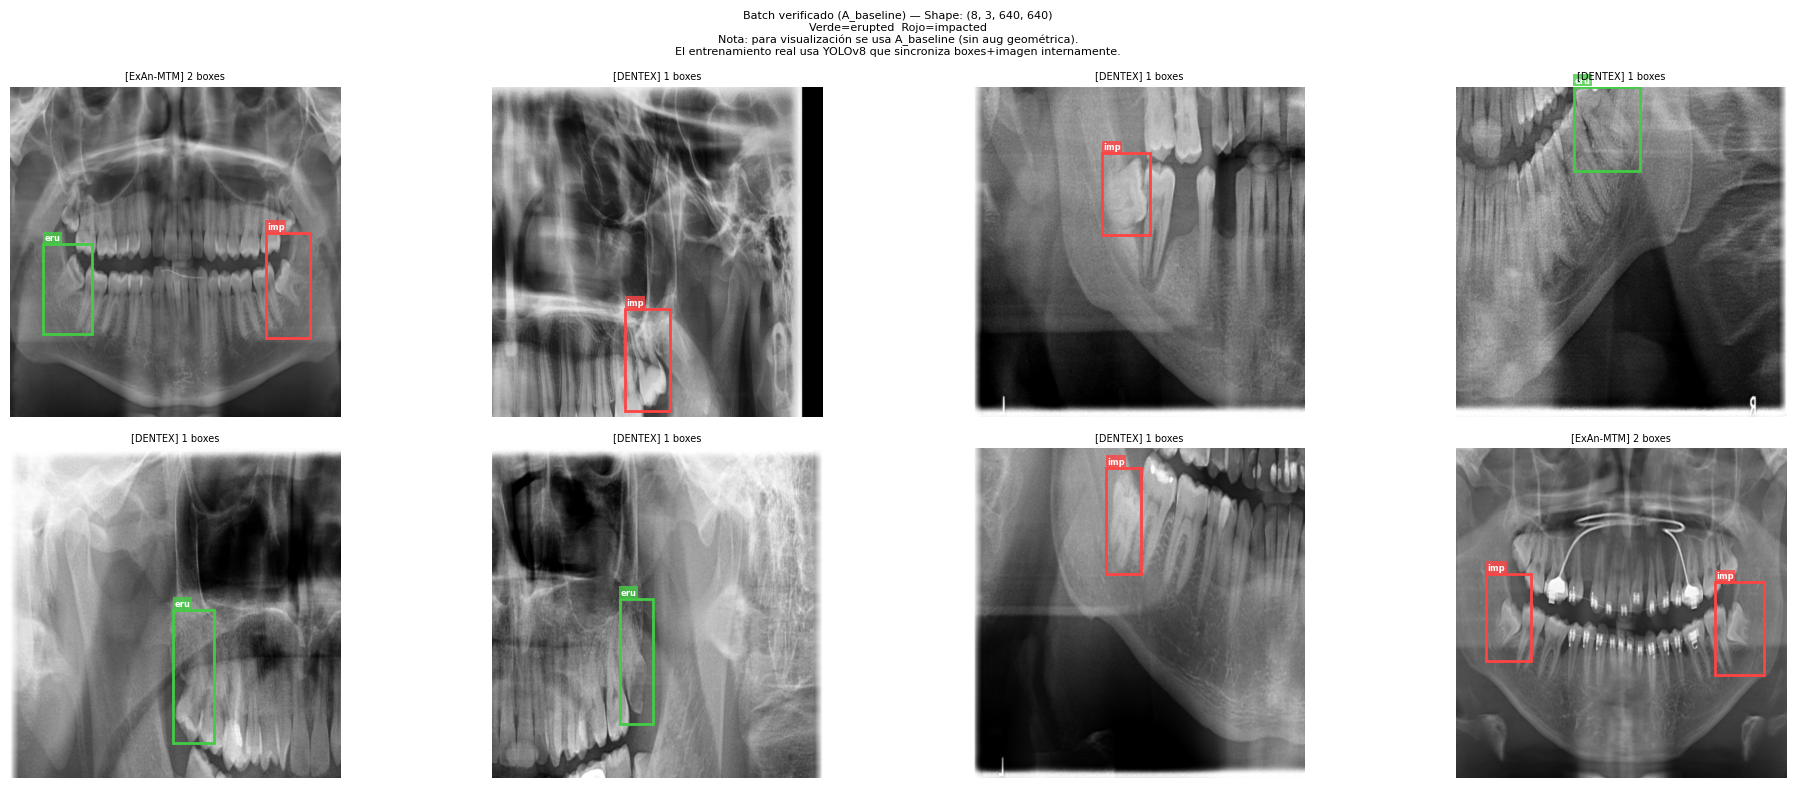

In [8]:
batch_imgs, batch_targets = next(iter(dl_verify))
log(f'Shape:  {tuple(batch_imgs.shape)}  (batch × canales × alto × ancho)', 'DATA')
log(f'Dtype:  {batch_imgs.dtype}', 'DATA')
log(f'Rango:  [{batch_imgs.min():.3f}, {batch_imgs.max():.3f}]  (normalizado ImageNet)', 'DATA')
log(f'Boxes:  {[len(t["boxes"]) for t in batch_targets]} por imagen', 'DATA')
assert not torch.isnan(batch_imgs).any() and not torch.isinf(batch_imgs).any()
log('Sin NaN ni Inf', 'OK')

n_show = min(8, len(batch_targets))
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for idx, ax in enumerate(axes.flatten()):
    if idx >= n_show: ax.axis('off'); continue
    img_t = batch_imgs[idx]; target = batch_targets[idx]
    vis = (img_t*STD_T+MEAN_T).clamp(0,1).permute(1,2,0).numpy()
    ax.imshow(vis)
    for box, lbl in zip(target['boxes'], target['labels']):
        xc,yc,bw,bh = box.tolist(); x1,y1 = (xc-bw/2)*640, (yc-bh/2)*640
        color = '#FF4444' if lbl==1 else '#44CC44'
        ax.add_patch(patches.Rectangle((x1,y1),bw*640,bh*640,linewidth=2,edgecolor=color,facecolor='none'))
        ax.text(x1+2,y1-8,'imp' if lbl==1 else 'eru',color='white',fontsize=6,fontweight='bold',
                bbox=dict(facecolor=color,alpha=0.8,pad=1,edgecolor='none'))
    fuente = 'DENTEX' if target['image_id'].startswith('dentex_') else 'ExAn-MTM'
    ax.set_title(f'[{fuente}] {len(target["boxes"])} boxes', fontsize=7); ax.axis('off')
plt.suptitle(
    f'Batch verificado (A_baseline) — Shape: {tuple(batch_imgs.shape)}\n'
    f'Verde=erupted  Rojo=impacted\n'
    f'Nota: para visualización se usa A_baseline (sin aug geométrica).\n'
    f'El entrenamiento real usa YOLOv8 que sincroniza boxes+imagen internamente.',
    fontsize=8)
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR/'batch_verificacion.png'), dpi=100, bbox_inches='tight')
plt.show()

## f) Exportar CSVs de splits

Se exportan a `data/` del repo para versionarlos en Git.
Garantizan que cualquier clon del repo use exactamente el mismo particionado.


In [9]:
# Guardar CSVs — detectar path real del repo
import os
if os.path.exists('/content/dentex-wisdom-teeth'):
    # Kernel Colab corriendo en Colab real
    csv_base = Path('/content/dentex-wisdom-teeth/data')
elif os.path.exists('C:/Users/Usuario/dentex-wisdom-teeth'):
    # VS Code con kernel Colab remoto — filesystem local Windows
    csv_base = Path('C:/Users/Usuario/dentex-wisdom-teeth/data')
else:
    csv_base = DATA_DIR

csv_base.mkdir(parents=True, exist_ok=True)
log(f'Guardando CSVs en: {csv_base}', 'DATA')

for split in ['train','val','test']:
    rows=[]
    img_dir=YOLO_MERGED/'images'/split; lbl_dir=YOLO_MERGED/'labels'/split
    for img_path in sorted(list(img_dir.glob('*.png'))+list(img_dir.glob('*.jpg'))):
        lbl_path=lbl_dir/(img_path.stem+'.txt')
        if not lbl_path.exists(): continue
        classes=[int(l.split()[0]) for l in lbl_path.read_text().strip().split('\n') if l]
        rows.append({'filename':img_path.name,'split':split,
                     'origen':'dentex' if img_path.name.startswith('dentex_') else 'exan',
                     'img_class':'impacted' if 1 in classes else 'erupted',
                     'n_boxes':len(classes),'n_erupted':classes.count(0),'n_impacted':classes.count(1)})
    df=pd.DataFrame(rows)
    df.to_csv(csv_base/f'{split}.csv', index=False)
    eru=(df.img_class=='erupted').sum(); imp=(df.img_class=='impacted').sum()
    log(f'CSV {split}: {len(df)} filas | erupted={eru} ({eru/len(df)*100:.0f}%) impacted={imp} ({imp/len(df)*100:.0f}%)','OK')

log(f'CSVs guardados en {csv_base}','OK')

[DATA] Guardando CSVs en: /content/dentex-wisdom-teeth/data
[OK]   CSV train: 2619 filas | erupted=983 (38%) impacted=1636 (62%)
[OK]   CSV val: 120 filas | erupted=43 (36%) impacted=77 (64%)
[OK]   CSV test: 110 filas | erupted=47 (43%) impacted=63 (57%)
[OK]   CSVs guardados en /content/dentex-wisdom-teeth/data


In [6]:
DRIVE_DIR = Path('/drive/MyDrive/dentex_runs')

In [14]:
import subprocess, sys, os, gc, json, random, warnings, shutil
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings('ignore')

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *pkgs, '-q'])

try: import ultralytics, sklearn
except ImportError: pip_install('ultralytics','scikit-learn')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from sklearn.metrics import classification_report
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from ultralytics import YOLO

def log(msg, level='INFO'):
    icons={'INFO':'[INFO]','OK':'[OK]  ','WARN':'[WARN]','ERR':'[ERR] ','DATA':'[DATA]'}
    print(f'{icons.get(level,"[INFO]")} {msg}')

def clear_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# ── Detección automática Colab / local ────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = os.path.exists('/content') and not os.path.exists('C:/Users')
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive; drive.mount('/drive')
    REPO_ROOT = Path('/content/dentex-wisdom-teeth')
    if not REPO_ROOT.exists():
        subprocess.run(['git', 'clone',
                        'https://github.com/JulianOliveraBalls/dentex-wisdom-teeth.git',
                        str(REPO_ROOT)], check=True)
    DRIVE_DIR = Path('/drive/MyDrive/dentex_runs')
else:
    _nb_path = Path(globals().get('__vsc_ipynb_file__',
                    globals().get('__file__', str(Path.cwd() / 'dev' / 'notebook.ipynb'))))
    REPO_ROOT = _nb_path.parent.parent
    DRIVE_DIR = REPO_ROOT / 'dev'
    log(f'Modo local — REPO_ROOT: {REPO_ROOT}', 'OK')

DATA_DIR    = REPO_ROOT / 'data'
OUTPUTS_DIR = DATA_DIR / 'outputs'
SRC_DIR     = REPO_ROOT / 'src'
DEV_DIR     = REPO_ROOT / 'dev'
for d in [OUTPUTS_DIR, DEV_DIR]: d.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(SRC_DIR))

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Buscar yolo_merged en ubicaciones posibles ────────────────────────────────
_candidatos = [
    DATA_DIR / 'processed' / 'yolo_merged',
    Path('/content/data/processed/yolo_merged'),
    Path('/content/dentex-wisdom-teeth/data/processed/yolo_merged'),
]
YOLO_MERGED = None
for c in _candidatos:
    if c.exists() and len(list((c/'images'/'train').glob('*.*'))) > 100:
        YOLO_MERGED = c; break

if YOLO_MERGED is None:
    raise RuntimeError(
        'yolo_merged no encontrado.\n'
        'Correr primero 01_dataset_preparation.ipynb en esta sesión.')

log(f'REPO_ROOT: {REPO_ROOT}', 'DATA')
log(f'IN_COLAB: {IN_COLAB}   device: {device}', 'OK')
log(f'yolo_merged: {YOLO_MERGED}', 'DATA')
log(f'  train: {len(list((YOLO_MERGED/"images"/"train").glob("*.*")))} imgs', 'DATA')

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
[DATA] REPO_ROOT: /content/dentex-wisdom-teeth
[OK]   IN_COLAB: True   device: cuda
[DATA] yolo_merged: /content/dentex-wisdom-teeth/data/processed/yolo_merged
[DATA]   train: 2619 imgs


In [15]:

# 1. Generar augmentations offline sobre yolo_merged (solo transforms safe)
# Safe = no geométricas → no invalidan boxes
import sys
sys.path.insert(0, str(SRC_DIR))
from augmentations_config import AUGMENTATIONS
import torchvision.transforms as T

MEAN_T = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
STD_T  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

YOLO_G7 = DATA_DIR / 'processed' / 'yolo_g7'

def generar_aug_offline(src, dst, aug_names=('C_color', 'F_mixaug')):
    """
    Copia el dataset src a dst y agrega versiones aumentadas de train
    usando solo augmentations que NO mueven píxeles (safe para boxes).
    C_color: ColorJitter + RandomAffine(5°) — affine leve, aceptable
    F_mixaug: ColorJitter + GaussianBlur + RandomErasing
    """
    # Copiar val y test sin cambios
    for split in ['val', 'test']:
        for sub in ['images', 'labels']:
            (dst/sub/split).mkdir(parents=True, exist_ok=True)
            for f in (src/sub/split).glob('*.*'):
                lnk = dst/sub/split/f.name
                if not lnk.exists(): os.symlink(f.resolve(), lnk)

    # Train: copiar originales + generar versiones aumentadas
    (dst/'images'/'train').mkdir(parents=True, exist_ok=True)
    (dst/'labels'/'train').mkdir(parents=True, exist_ok=True)
    n_orig = n_aug = 0

    for img_path in sorted(list((src/'images'/'train').glob('*.png')) +
                            list((src/'images'/'train').glob('*.jpg'))):
        lbl_path = src/'labels'/'train'/(img_path.stem+'.txt')
        if not lbl_path.exists(): continue

        # Original
        di = dst/'images'/'train'/img_path.name
        dl = dst/'labels'/'train'/lbl_path.name
        if not di.exists():
            real = Path(os.path.realpath(str(img_path)))
            if real.exists() and real != di: os.symlink(real, di)
            else: shutil.copy2(str(img_path), str(di))
        if not dl.exists(): shutil.copy2(str(lbl_path), str(dl))
        n_orig += 1

        # Versiones aumentadas
        pil = Image.open(img_path).convert('RGB')
        for aug_name in aug_names:
            transform = AUGMENTATIONS[aug_name]
            aug_t = transform(pil)
            # Desnormalizar → PIL para guardar
            aug_img = (aug_t * STD_T + MEAN_T).clamp(0, 1)
            aug_pil = T.ToPILImage()(aug_img)
            stem = f'{img_path.stem}_aug_{aug_name}'
            aug_pil.save(str(dst/'images'/'train'/(stem+'.png')))
            # Mismo label — boxes válidos porque no hay transforms geométricas
            shutil.copy2(str(lbl_path), str(dst/'labels'/'train'/(stem+'.txt')))
            n_aug += 1

    # dataset.yaml con test ampliado
    (dst/'dataset.yaml').write_text(
        f'path: {dst}\ntrain: images/train\nval: images/val\n'
        f'test: images/test\nnc: 2\nnames:\n  0: erupted\n  1: impacted\n')
    return n_orig, n_aug

def split_existe(d):
    return Path(d).exists() and all(
        len(list((Path(d)/'images'/s).glob('*.*'))) > 0
        for s in ['train','val','test'])

if split_existe(YOLO_G7) and len(list((YOLO_G7/'images'/'train').glob('*aug*'))) > 0:
    n_train = len(list((YOLO_G7/'images'/'train').glob('*.*')))
    log(f'yolo_g7 ya existe: {n_train} imgs train', 'OK')
else:
    if YOLO_G7.exists(): shutil.rmtree(str(YOLO_G7))
    log('Generando yolo_g7 con aug offline...', 'WARN')
    n_orig, n_aug = generar_aug_offline(YOLO_MERGED, YOLO_G7)
    n_train = len(list((YOLO_G7/'images'/'train').glob('*.*')))
    log(f'yolo_g7: {n_orig} orig + {n_aug} aug = {n_train} imgs train', 'OK')

[WARN] Generando yolo_g7 con aug offline...
[OK]   yolo_g7: 2619 orig + 5238 aug = 7857 imgs train


In [16]:
from ultralytics import YOLO
from pathlib import Path

def log(msg, level='INFO'):
    icons = {'INFO':'[INFO]','OK':'[OK]  ','WARN':'[WARN]','ERR':'[ERR] ','DATA':'[DATA]'}
    print(f'{icons.get(level,"[INFO]")} {msg}')

YOLO_G7   = Path('/content/dentex-wisdom-teeth/data/processed/yolo_g7')

weights = DRIVE_DIR / 'Exp_G7_todo_junto' / 'weights' / 'last.pt'
log(f'Usando: {weights.name}  ({weights.stat().st_size/1e6:.1f} MB)', 'OK')

model_G7 = YOLO(str(weights))
metrics_G7 = model_G7.val(
    data=str(YOLO_G7 / 'dataset.yaml'),
    split='test', imgsz=640, batch=8, verbose=True)


[OK]   Usando: last.pt  (52.0 MB)
Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 201.6±54.2 MB/s, size: 4437.7 KB)
val: Scanning /content/dentex-wisdom-teeth/data/processed/yolo_g7/labels/test... 110 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 110/110 46.7it/s 2.4s0.1s
val: New cache created: /content/dentex-wisdom-teeth/data/processed/yolo_g7/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.9it/s 7.5s0.3s
                   all        110        215       0.68      0.675      0.636      0.365
               erupted         60         84       0.45      0.488       0.35      0.206
              impacted         63        131      0.909      0.863      0.922      0.525
Speed: 1.4ms preprocess, 17.8ms inference, 0.0ms loss, 4.0ms p

In [17]:
# ── Exp_G8: Fine-tuning single-class impacted ─────────────────────────────
import shutil, os
from pathlib import Path
from PIL import Image

YOLO_G8 = DATA_DIR / 'processed' / 'yolo_g8_impacted'

def build_impacted_dataset(src: Path, dst: Path) -> dict:
    """
    Construye un dataset single-class a partir de yolo_g7:
      - Filtra imágenes que tienen al menos 1 anotación impacted (cls=1)
      - Reetiqueta: cls=1 → cls=0 (única clase del nuevo dataset)
      - Elimina anotaciones erupted (cls=0 original)
      - Copia imágenes y genera labels filtrados
    
    val y test: mismos splits que G7 (mismas imágenes, solo filtradas)
    """
    stats = {}
    
    for split in ['train', 'val', 'test']:
        img_out = dst / 'images' / split
        lbl_out = dst / 'labels' / split
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)
        
        n_imgs = n_anns = 0
        lbl_dir = src / 'labels' / split
        img_dir = src / 'images' / split
        
        for lbl_path in sorted(lbl_dir.glob('*.txt')):
            lines = lbl_path.read_text().strip().split('\n')
            
            # Filtrar solo anotaciones impacted (cls=1 en G7 → cls=0 en G8)
            impacted_lines = []
            for line in lines:
                if line.strip() and int(line.split()[0]) == 1:
                    # Reetiqueta: cls=1 → cls=0
                    parts = line.split()
                    parts[0] = '0'
                    impacted_lines.append(' '.join(parts))
            
            # Solo incluir si tiene al menos 1 impacted
            if not impacted_lines:
                continue
            
            # Buscar imagen correspondiente (.jpg o .png)
            img_src = None
            for ext in ['.jpg', '.jpeg', '.png']:
                candidate = img_dir / (lbl_path.stem + ext)
                # Resolver symlinks
                real = Path(os.path.realpath(str(candidate)))
                if real.exists():
                    img_src = real
                    break
            
            if img_src is None:
                continue
            
            # Copiar imagen y label filtrado
            dst_img = img_out / (lbl_path.stem + img_src.suffix)
            dst_lbl = lbl_out / lbl_path.name
            
            if not dst_img.exists():
                shutil.copy2(str(img_src), str(dst_img))
            dst_lbl.write_text('\n'.join(impacted_lines))
            
            n_imgs += 1
            n_anns += len(impacted_lines)
        
        stats[split] = {'imgs': n_imgs, 'anns': n_anns}
        log(f'G8 {split:5s}: {n_imgs} imgs, {n_anns} anotaciones impacted', 'DATA')
    
    # dataset.yaml single-class
    (dst / 'dataset.yaml').write_text(
        f'path: {dst}\n'
        f'train: images/train\n'
        f'val:   images/val\n'
        f'test:  images/test\n'
        f'nc: 1\n'
        f'names:\n'
        f'  0: impacted\n'
    )
    
    return stats


# Construir dataset G8 (o verificar si ya existe)
def dataset_g8_ok(d):
    return (Path(d) / 'dataset.yaml').exists() and \
           len(list((Path(d) / 'images' / 'train').glob('*.*'))) > 100

if dataset_g8_ok(YOLO_G8):
    n_train = len(list((YOLO_G8 / 'images' / 'train').glob('*.*')))
    log(f'yolo_g8 ya existe: {n_train} imgs train', 'OK')
else:
    if YOLO_G8.exists():
        shutil.rmtree(str(YOLO_G8))
    log('Construyendo yolo_g8_impacted...', 'WARN')
    stats = build_impacted_dataset(YOLO_G7, YOLO_G8)
    log(f'Dataset G8 listo — train: {stats["train"]["imgs"]} imgs', 'OK')

[WARN] Construyendo yolo_g8_impacted...
[DATA] G8 train: 4908 imgs, 7137 anotaciones impacted
[DATA] G8 val  : 77 imgs, 147 anotaciones impacted
[DATA] G8 test : 63 imgs, 131 anotaciones impacted
[OK]   Dataset G8 listo — train: 4908 imgs


In [18]:
# ── Entrenar Exp_G8 ───────────────────────────────────────────────────────
import threading, time

# Restaurar G7 last.pt como punto de partida
run_g8_dst = Path('runs/detect/Exp_G8_impacted/weights')
run_g8_dst.mkdir(parents=True, exist_ok=True)

g7_weights = DRIVE_DIR / 'Exp_G7_todo_junto' / 'weights' / 'last.pt'
assert g7_weights.exists(), f'No se encontró G7 last.pt en {g7_weights}'
log(f'Partiendo de G7 last.pt ({g7_weights.stat().st_size/1e6:.1f} MB)', 'OK')

# Autoguardado en Drive
def autoguardar_g8(drive_dir, intervalo_min=10):
    run_path = Path('runs/detect/Exp_G8_impacted')
    dst = Path(drive_dir) / 'Exp_G8_impacted'
    (dst / 'weights').mkdir(parents=True, exist_ok=True)
    while True:
        time.sleep(intervalo_min * 60)
        try:
            for fname in ['last.pt', 'best.pt']:
                src = run_path / 'weights' / fname
                if src.exists():
                    shutil.copy2(str(src), str(dst / 'weights' / fname))
            csv = run_path / 'results.csv'
            if csv.exists():
                shutil.copy2(str(csv), str(dst / 'results.csv'))
            log('G8 checkpoint guardado en Drive', 'OK')
        except Exception as e:
            log(f'Error autoguardado G8: {e}', 'WARN')

t = threading.Thread(target=autoguardar_g8, args=(str(DRIVE_DIR),), daemon=True)
t.start()
log('Autoguardado G8 cada 10 min activado', 'OK')

# Fine-tuning desde G7
# lr0=0.0001 — 10x menor que G7 para no destruir features
# patience=10 — early stopping agresivo (20 epochs máx)
# single_cls=False — nc=1 ya lo define el dataset.yaml
model_G8 = YOLO(str(g7_weights))

results_G8 = model_G8.train(
    data=str(YOLO_G8 / 'dataset.yaml'),
    name='Exp_G8_impacted',
    epochs=20,
    imgsz=640,
    batch=8,
    workers=2,
    # LR muy bajo — fine-tuning suave
    optimizer='AdamW',
    lr0=0.0001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=2,
    # Augmentations conservadoras — igual que G7
    fliplr=0.5,
    hsv_v=0.2,
    degrees=5.0,
    translate=0.05,
    mosaic=0.0,
    mixup=0.0,
    # Early stopping
    patience=10,
    # Resto
    plots=True,
    verbose=False,
    exist_ok=True,
)

[OK]   Partiendo de G7 last.pt (52.0 MB)
[OK]   Autoguardado G8 cada 10 min activado
Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dentex-wisdom-teeth/data/processed/yolo_g8_impacted/dataset.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/drive/MyDrive/dentex_runs/Exp_G7_t

In [19]:
# ── Evaluar G8 en test ────────────────────────────────────────────────────
best_g8 = Path('runs/detect/Exp_G8_impacted/weights/best.pt')
last_g8 = Path('runs/detect/Exp_G8_impacted/weights/last.pt')
weights_g8 = best_g8 if best_g8.exists() else last_g8

log(f'Evaluando G8 con: {weights_g8.name}', 'OK')
model_G8_eval = YOLO(str(weights_g8))

metrics_G8 = model_G8_eval.val(
    data=str(YOLO_G8 / 'dataset.yaml'),
    split='test',
    imgsz=640,
    batch=8,
    verbose=True,
)

log('Exp_G8 — Test (single-class impacted):', 'DATA')
log(f'  mAP50 impacted: {metrics_G8.box.map50:.3f}', 'DATA')
log(f'  P: {metrics_G8.box.mp:.3f}  R: {metrics_G8.box.mr:.3f}', 'DATA')

# Comparación directa con G7 en la misma clase
log('', 'INFO')
log('Comparación impacted mAP50:', 'DATA')
log(f'  G7 (two-class): 0.951', 'DATA')
log(f'  G8 (single-class fine-tune): {metrics_G8.box.map50:.3f}', 'DATA')
delta = metrics_G8.box.map50 - 0.951
log(f'  Delta: {delta:+.3f}', 'OK' if delta >= 0 else 'WARN')

[OK]   Evaluando G8 con: best.pt
Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 215.6±38.7 MB/s, size: 3983.8 KB)
val: Scanning /content/dentex-wisdom-teeth/data/processed/yolo_g8_impacted/labels/test... 63 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 63/63 60.9it/s 1.0s0.0s
val: New cache created: /content/dentex-wisdom-teeth/data/processed/yolo_g8_impacted/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.2it/s 6.5s0.7ss
                   all         63        131      0.913      0.901      0.942      0.584
Speed: 3.6ms preprocess, 15.4ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to /content/runs/detect/val-3
[DATA] Exp_G8 — Test (single-class impacted):
[DATA]   mAP50 impacted: 0.942
[DATA]   P: 0.913  R: 0

In [1]:
# ── Guardar G8 en Drive ───────────────────────────────────────────────────
dst_g8_drive = DRIVE_DIR / 'Exp_G8_impacted'
(dst_g8_drive / 'weights').mkdir(parents=True, exist_ok=True)

for fname in ['best.pt', 'last.pt']:
    src = Path('runs/detect/Exp_G8_impacted/weights') / fname
    if src.exists():
        shutil.copy2(str(src), str(dst_g8_drive / 'weights' / fname))
        log(f'G8 {fname} → Drive ({src.stat().st_size/1e6:.1f} MB)', 'OK')

csv_g8 = Path('runs/detect/Exp_G8_impacted/results.csv')
if csv_g8.exists():
    shutil.copy2(str(csv_g8), str(dst_g8_drive / 'results.csv'))
    log('G8 results.csv → Drive', 'OK')

log(f'Exp_G8 completo — Drive: {dst_g8_drive}', 'OK')

NameError: name 'DRIVE_DIR' is not defined

In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import random

model = YOLO('/drive/MyDrive/dentex_runs/Exp_G8_impacted/weights/best.pt')

test_imgs = list((YOLO_G8 / 'images' / 'test').glob('*.*'))
random.shuffle(test_imgs)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, img_path in enumerate(test_imgs[:6]):
    # Resolver symlink
    real_path = Path(img_path).resolve()
    img = cv2.imread(str(real_path))
    if img is None:
        continue
    
    results = model.predict(str(real_path), conf=0.25, imgsz=640, verbose=False)[0]
    
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        conf = float(box.conf)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 80, 220), 2)
        cv2.putText(img, f"imp {conf:.2f}", (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 80, 220), 2)
    
    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"{img_path.name[:30]} — {len(results.boxes)} det")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Setup completo en una celda
!pip install ultralytics -q

from google.colab import drive
drive.mount('/drive')

import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import random

DRIVE_DIR = Path('/drive/MyDrive/dentex_runs')
YOLO_G8   = Path('/content/dentex-wisdom-teeth/data/processed/yolo_g8_impacted')

# Si perdiste la sesión yolo_g8 no existe — usá las imágenes de test de yolo_merged
test_dir = YOLO_G8 / 'images' / 'test'
if not test_dir.exists():
    print("yolo_g8 no existe en esta sesión — usando test de yolo_merged")
    test_dir = Path('/content/dentex-wisdom-teeth/data/processed/yolo_merged/images/test')

if not test_dir.exists():
    print("Clonando repo...")
    import subprocess
    subprocess.run(['git', 'clone', 
                    'https://github.com/JulianOliveraBalls/dentex-wisdom-teeth.git',
                    '/content/dentex-wisdom-teeth'], check=True)

model = YOLO(str(DRIVE_DIR / 'Exp_G8_impacted/weights/best.pt'))

test_imgs = list(test_dir.glob('*.*'))
random.shuffle(test_imgs)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, img_path in enumerate(test_imgs[:6]):
    real_path = Path(img_path).resolve()
    img = cv2.imread(str(real_path))
    if img is None:
        continue
    
    results = model.predict(str(real_path), conf=0.25, imgsz=640, verbose=False)[0]
    
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        conf = float(box.conf)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 80, 220), 2)
        cv2.putText(img, f"imp {conf:.2f}", (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    h = img.shape[0]
    n_sup = sum(1 for b in results.boxes if int(b.xyxy[0][1]) < h//2)
    n_inf = len(results.boxes) - n_sup
    
    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"{img_path.name[:25]} | sup={n_sup} inf={n_inf}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'ultralytics'